In [1]:
import sys
sys.path.append('../')
import matplotlib.pyplot as plt
import numpy as np
import json
import os
from qiskit.quantum_info import SparsePauliOp
from collections import Counter

In [2]:
# Extract classical results
cs_dir = "../classical_search/cs_res/"

def relabel_turns(turns: str) -> str:
    """Relabels the turns from the classical search to the ones used in the quantum search."""
    mapping = {
        "0": "0",
        "1": "2", 
        "2": "4",
        "3": "6",
        "4": "8",
        "5": "a",
        "6": "1",
        "7": "3",
        "8": "5",
        "9": "7",
        "a": "9",
        "b": "b"
    }
    return "".join([mapping[turn] for turn in turns])


def load_top_cls_solns(file_name: str) -> list:
    top_cls_turns = []
    with open(cs_dir + file_name, "r") as file:
        data = file.read()
        # Split by line
        data_by_line = data.split("\n")
        for line in data_by_line:
            if len(line.split("\t")) == 2:
                [energy, turns] = line.split("\t")
                top_cls_turns.append([relabel_turns(turns), float(energy)])
    return top_cls_turns

def convert_bitstring_to_turns(soln_bitstring: str, main_seq: str) -> str:
    """Converts a solution bitstring (given by the quantum algorithm) to the
    turns."""
    encoding = {
        "0000": "0",
        "0011": "1",
        "1100": "2",
        "1111": "3",
        "1001": "4",
        "0101": "5",
        "1010": "6",
        "0110": "7",
        "1000": "8",
        "0100": "9",
        "1011": "a",
        "0111": "b",
        "0001": "x", # unphysical
        "0010": "x", # unphysical
        "1101": "x", # unphysical
        "1110": "x", # unphysical
    }
    peptide_len = len(main_seq)
    config_bitstring = soln_bitstring[-(4 * peptide_len - 10) :]
    # Add the first 4 bits corresponding to the fixed first turn (0000)
    full_config_bitstring = config_bitstring + "0000"
    # Add the two qubits at positions 6 & 7 from the right (00)
    full_config_bitstring = (
        full_config_bitstring[:-6] + "00" + full_config_bitstring[-6:]
    )
    # Reverse the bitstring
    full_config_bitstring = full_config_bitstring[::-1]
    length_turns = len(full_config_bitstring) // 4
    turns = ""
    for i in range(length_turns):
        turn = full_config_bitstring[i * 4 : (i + 1) * 4]
        turns += encoding[turn]
    # Reverse the turns
    return turns[::-1]

Load the sampler results

In [3]:
# Path to the folder with saved sampling results from mps sim, using opt parameters from interval2rerun1
base_dir = "../res/fcc_hw/KLVFFA_2025-05-20-20-18-29_aer_simulator_matrix_product_state_sampled"

# Full paths to the JSON files
metadata_path = os.path.join(base_dir, "metadata.json")
sampling_results_path = os.path.join(base_dir, "sampling_results.json")

# Load metadata
with open(metadata_path, "r") as f:
    metadata = json.load(f)

# Load sampling results
with open(sampling_results_path, "r") as f:
    sampling_data = json.load(f)

print("There are a total of", len(sampling_data), "bitstrings.")


There are a total of 38472 bitstrings.


Convert the bitstrings into turn sequences and drop the unphysical ones (containing the turns with "x")

In [4]:
main_seq = metadata["main_seq"]

turn_seq_triplets = []
dropped_count = 0

for bitstring, count in sampling_data.items():
    turn_seq = convert_bitstring_to_turns(bitstring, main_seq)
    if "x" in turn_seq:
        dropped_count += 1
        continue
    turn_seq_triplets.append([turn_seq, bitstring, count])

print(f"✅ Loaded {len(turn_seq_triplets)} valid bitstrings.")
print(f"❌ Dropped {dropped_count} unphysical turn sequences (with 'x').")

✅ Loaded 14758 valid bitstrings.
❌ Dropped 23714 unphysical turn sequences (with 'x').


In [5]:
# Get top 100 solutions from classical search results
top_cls_solns = load_top_cls_solns(f"{len(metadata['main_seq'])}AA_{metadata['main_seq']}_topobj.txt")[:100]
top_cls_solns[:10]

[['97490', -30.57],
 ['a9720', -30.55],
 ['8b520', -30.55],
 ['70b90', -30.45],
 ['81490', -30.45],
 ['31a20', -30.43],
 ['31820', -30.43],
 ['2b580', -30.43],
 ['9a180', -30.43],
 ['5b580', -30.33]]

Plot and analyze the results

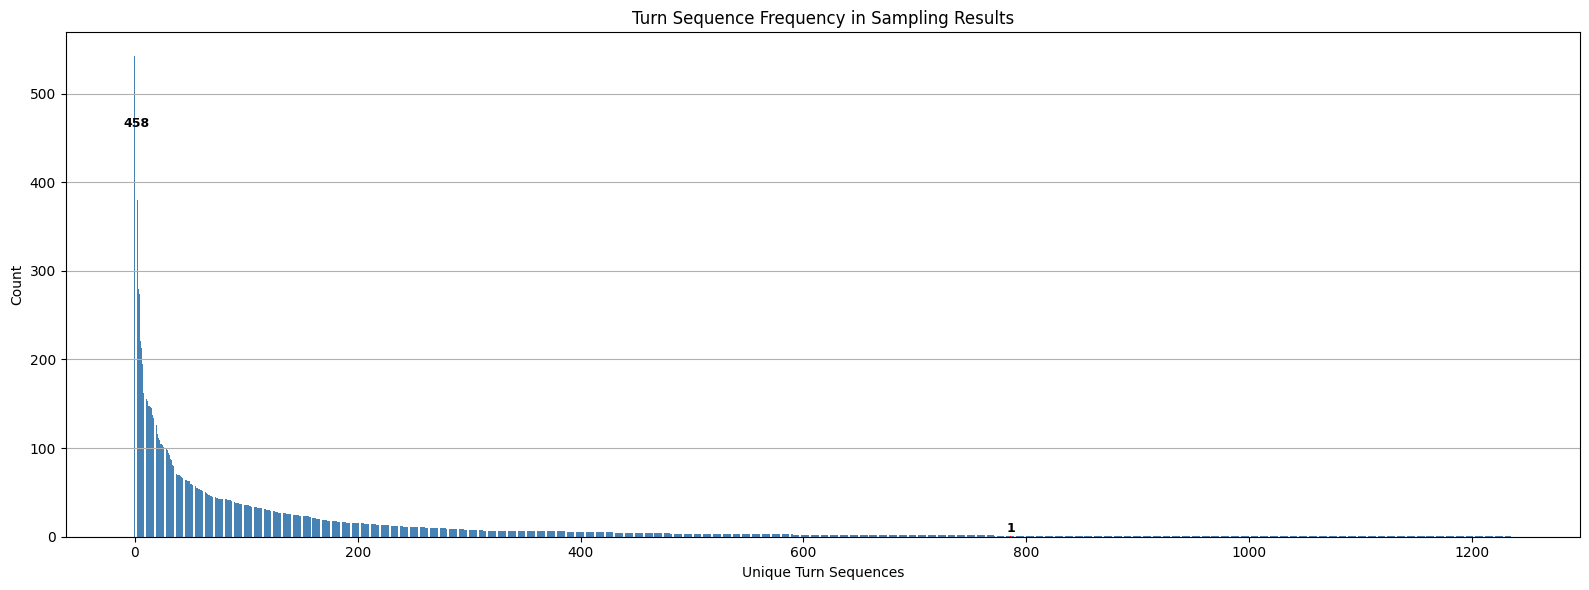

🔍 Counts and percentages of top classical solutions in sampled data:
 - 97490: 0 (0.00%)
 - a9720: 458 (3.10%)
 - 8b520: 0 (0.00%)
 - 70b90: 0 (0.00%)
 - 81490: 0 (0.00%)
 - 31a20: 0 (0.00%)
 - 31820: 0 (0.00%)
 - 2b580: 1 (0.01%)
 - 9a180: 0 (0.00%)
 - 5b580: 0 (0.00%)


In [6]:
# --- Step 1: Define top classical turn sequences ---
top_cls_turns = ['97490', 'a9720', '8b520', '70b90', '81490', '31a20', '31820', '2b580', '9a180', '5b580']
cls_turn_set = set(top_cls_turns)

# --- Step 2: Build histogram data from turn_seq_triplets ---
turn_strs = [''.join(seq) for seq, _, _ in turn_seq_triplets]
turn_counts = Counter(turn_strs)

# Sort by frequency (or alphabetically if you want full order)
sorted_turns = sorted(turn_counts.keys(), key=lambda t: -turn_counts[t])  # sort by descending count

x_vals = list(range(len(sorted_turns)))
y_vals = [turn_counts[turn] for turn in sorted_turns]

# --- Step 3: Plot histogram ---
bar_colors = ['red' if turn in cls_turn_set else 'steelblue' for turn in sorted_turns]

plt.figure(figsize=(16, 6))
bars = plt.bar(x_vals, y_vals, color=bar_colors)

# Annotate red bars with count
for idx, turn in enumerate(sorted_turns):
    if turn in cls_turn_set:
        plt.text(
            x_vals[idx],
            y_vals[idx] + 1,
            str(turn_counts[turn]),
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold',
            color='black'
        )

plt.xlabel("Unique Turn Sequences")
plt.ylabel("Count")
plt.title("Turn Sequence Frequency in Sampling Results")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

# --- Step 4: Print how many times each top classical turn appeared ---
total_counts = sum(turn_counts.values())

print("🔍 Counts and percentages of top classical solutions in sampled data:")
for turn in top_cls_turns:
    count = turn_counts.get(turn, 0)
    percent = (count / total_counts) * 100 if total_counts > 0 else 0
    print(f" - {turn}: {count} ({percent:.2f}%)")



In [7]:
# Path to the folder with saved sampling results on hw, using opt parameters from interval2rerun1
base_dir = "../res/fcc_hw/KLVFFA_2025-05-20-20-39-51_ibm_cleveland_sampled"

# Full paths to the JSON files
metadata_path = os.path.join(base_dir, "metadata.json")
sampling_results_path = os.path.join(base_dir, "sampling_results.json")

# Load metadata
with open(metadata_path, "r") as f:
    metadata = json.load(f)

# Load sampling results
with open(sampling_results_path, "r") as f:
    sampling_data_hw = json.load(f)

print("There are a total of", len(sampling_data_hw), "bitstrings.")

There are a total of 93292 bitstrings.


In [8]:
main_seq = metadata["main_seq"]

turn_seq_triplets = []
dropped_count = 0

for bitstring, count in sampling_data_hw.items():
    turn_seq = convert_bitstring_to_turns(bitstring, main_seq)
    if "x" in turn_seq:
        dropped_count += 1
        continue
    turn_seq_triplets.append([turn_seq, bitstring, count])

print(f"✅ Loaded {len(turn_seq_triplets)} valid bitstrings.")
print(f"❌ Dropped {dropped_count} unphysical turn sequences (with 'x').")

✅ Loaded 36994 valid bitstrings.
❌ Dropped 56298 unphysical turn sequences (with 'x').


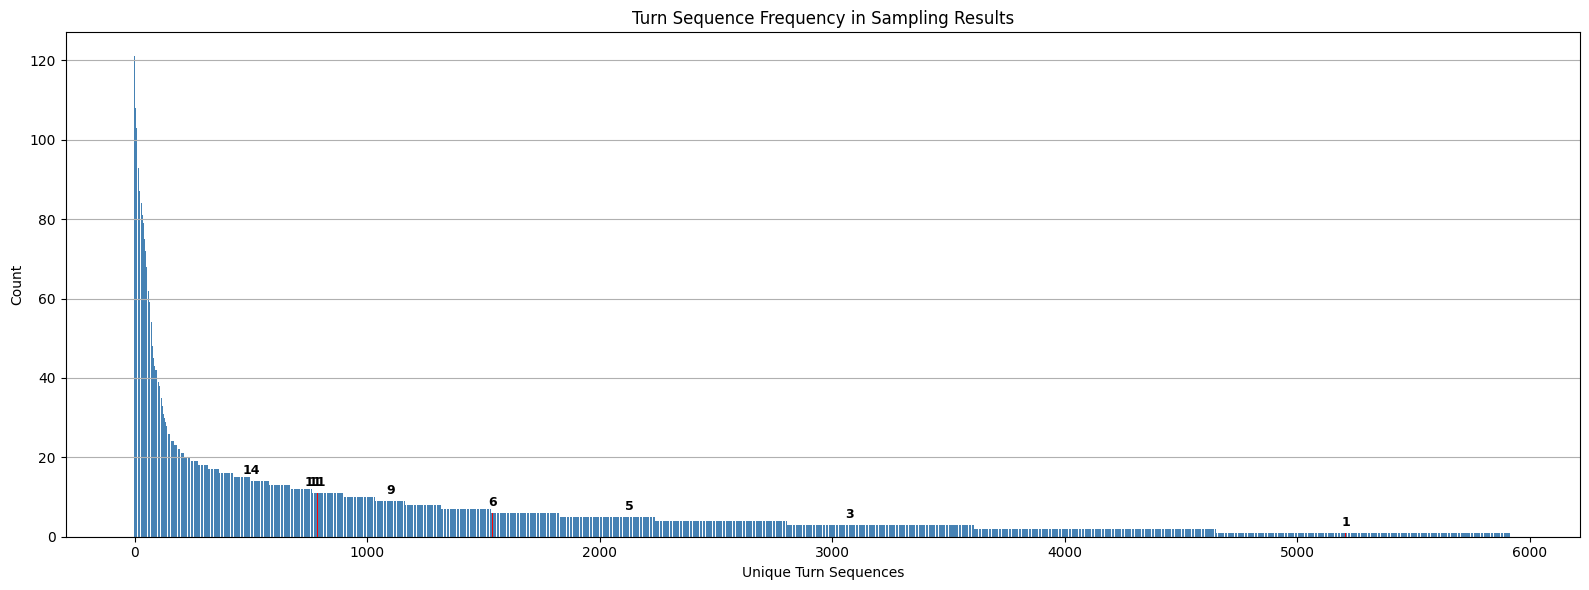

🔍 Counts and percentages of top classical solutions in sampled data:
 - 97490: 11 (0.03%)
 - a9720: 1 (0.00%)
 - 8b520: 6 (0.02%)
 - 70b90: 3 (0.01%)
 - 81490: 9 (0.02%)
 - 31a20: 0 (0.00%)
 - 31820: 0 (0.00%)
 - 2b580: 14 (0.04%)
 - 9a180: 5 (0.01%)
 - 5b580: 11 (0.03%)


In [9]:
# --- Step 1: Define top classical turn sequences ---
top_cls_turns = ['97490', 'a9720', '8b520', '70b90', '81490', '31a20', '31820', '2b580', '9a180', '5b580']
cls_turn_set = set(top_cls_turns)

# --- Step 2: Build histogram data from turn_seq_triplets ---
turn_strs = [''.join(seq) for seq, _, _ in turn_seq_triplets]
turn_counts = Counter(turn_strs)

# Sort by frequency (or alphabetically if you want full order)
sorted_turns = sorted(turn_counts.keys(), key=lambda t: -turn_counts[t])  # sort by descending count

x_vals = list(range(len(sorted_turns)))
y_vals = [turn_counts[turn] for turn in sorted_turns]

# --- Step 3: Plot histogram ---
bar_colors = ['red' if turn in cls_turn_set else 'steelblue' for turn in sorted_turns]

plt.figure(figsize=(16, 6))
bars = plt.bar(x_vals, y_vals, color=bar_colors)

# Annotate red bars with count
for idx, turn in enumerate(sorted_turns):
    if turn in cls_turn_set:
        plt.text(
            x_vals[idx],
            y_vals[idx] + 1,
            str(turn_counts[turn]),
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold',
            color='black'
        )

plt.xlabel("Unique Turn Sequences")
plt.ylabel("Count")
plt.title("Turn Sequence Frequency in Sampling Results")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

# --- Step 4: Print how many times each top classical turn appeared ---
total_counts = sum(turn_counts.values())

print("🔍 Counts and percentages of top classical solutions in sampled data:")
for turn in top_cls_turns:
    count = turn_counts.get(turn, 0)
    percent = (count / total_counts) * 100 if total_counts > 0 else 0
    print(f" - {turn}: {count} ({percent:.2f}%)")

